<a href="https://colab.research.google.com/github/shivaboss007/Coffee_Shop_Sales_Analysis/blob/main/Coffee_Shop_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df1=pd.read_csv("/content/index_1.csv")
df2=pd.read_csv("/content/index_2.csv")
#combine both
new_df=pd.concat([df1,df2],ignore_index=True)
new_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3898 non-null   object 
 1   datetime     3898 non-null   object 
 2   cash_type    3898 non-null   object 
 3   card         3547 non-null   object 
 4   money        3898 non-null   float64
 5   coffee_name  3898 non-null   object 
dtypes: float64(1), object(5)
memory usage: 182.8+ KB


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         262 non-null    object 
 1   datetime     262 non-null    object 
 2   cash_type    262 non-null    object 
 3   money        262 non-null    float64
 4   coffee_name  262 non-null    object 
dtypes: float64(1), object(4)
memory usage: 10.4+ KB


In [ ]:
new_df.describe()


,money
count,3898.00000
mean,31.38060
std,5.06461
min,15.00000
25%,27.92000
50%,32.82000
75%,35.76000
max,40.00000


In [ ]:
new_df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [ ]:
new_df.columns=new_df.columns.str.strip().str.lower()
new_df['card']=new_df['card'].fillna("unknown")
new_df['money']=pd.to_numeric(new_df['money'],errors='coerce')
new_df['cash_type']=new_df['cash_type'].str.strip().str.lower()
new_df['coffee_name']=new_df['coffee_name'].str.strip().str.title()

In [ ]:
new_df.tail()

,date,datetime,cash_type,card,money,coffee_name
3893,2025-03-23,2025-03-23 14:55:46,cash,unknown,30.0,Cappuccino
3894,2025-03-23,2025-03-23 15:15:36,card,unknown,25.0,Irish Whiskey
3895,2025-03-23,2025-03-23 17:59:25,card,unknown,28.0,Super Chocolate
3896,2025-03-23,2025-03-23 18:01:33,card,unknown,28.0,Vanilla With Irish Whiskey
3897,2025-03-23,2025-03-23 21:23:11,card,unknown,29.0,Coffee With Irish Whiskey


In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3898 non-null   object 
 1   datetime     3898 non-null   object 
 2   cash_type    3898 non-null   object 
 3   card         3898 non-null   object 
 4   money        3898 non-null   float64
 5   coffee_name  3898 non-null   object 
dtypes: float64(1), object(5)
memory usage: 182.8+ KB


In [ ]:
#Which coffees are most popular?
popular_coffees=new_df['coffee_name'].value_counts().reset_index().rename(columns={'coffee_name':'Coffee Name','count':'Number of Orders'})
print(popular_coffees.head(10))

                 Coffee Name  Number of Orders
0        Americano With Milk               868
1                      Latte               806
2                  Americano               593
3                 Cappuccino               517
4                    Cortado               292
5              Hot Chocolate               282
6                      Cocoa               243
7                   Espresso               152
8              Irish Whiskey                21
9  Coffee With Irish Whiskey                16


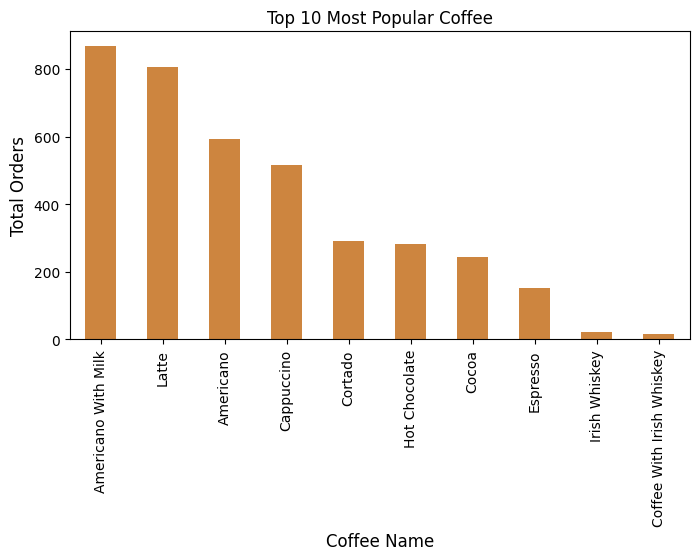

In [ ]:
import matplotlib.pyplot as plt
ax=popular_coffees.head(10).plot(
    figsize=(8,4),
    kind='bar',
    x='Coffee Name',
    y='Number of Orders',
    color='peru',
    title="Top 10 Most Popular Coffee",
    legend=False,

)
ax.set_xlabel("Coffee Name",fontsize=12)
ax.set_ylabel("Total Orders",fontsize=12)
plt.show()

In [ ]:
#Do people prefer card, cash, or UPI?
payment_prefer=new_df['cash_type'].value_counts()
print(payment_prefer.head(5))

cash_type
card    3729
cash     169
Name: count, dtype: int64


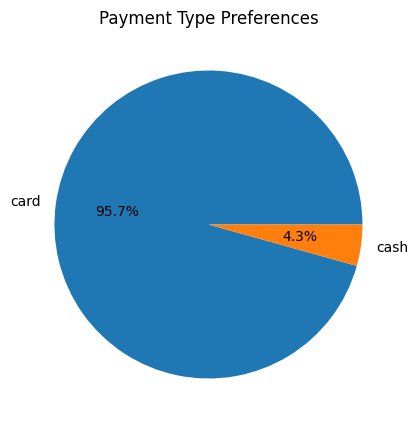

In [ ]:
import matplotlib.pyplot as plt
payment_prefer.plot(
    figsize=(5,5),
    kind='pie',
    y='count',
    #labels=payment_prefer['cash_type'],
    autopct="%1.1f%%",
    title='Payment Type Preferences',
    ylabel="",
    legend=False
)
plt.show()

In [ ]:
new_df['datetime']=pd.to_datetime(new_df['datetime'],errors='coerce')
new_df['hour']=new_df['datetime'].dt.hour
hourly_orders=new_df['hour'].value_counts().sort_index().reset_index()
print(hourly_orders)

    hour  count
0    6.0      5
1    7.0     91
2    8.0    235
3    9.0    247
4   10.0    349
5   11.0    294
6   12.0    249
7   13.0    227
8   14.0    228
9   15.0    245
10  16.0    283
11  17.0    244
12  18.0    220
13  19.0    235
14  20.0    171
15  21.0    197
16  22.0    116


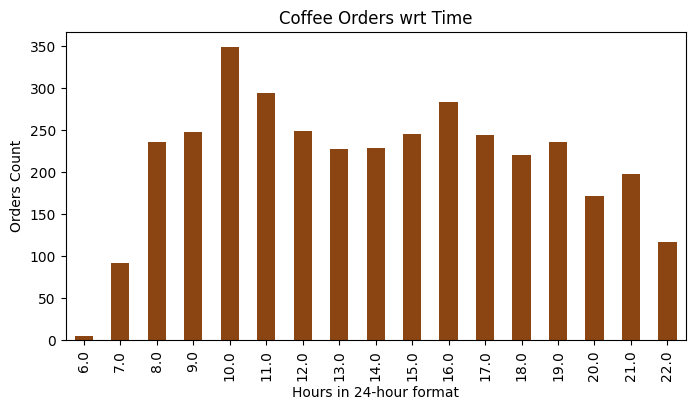

In [ ]:
hourly_orders.plot(
    figsize=(8,4),
    kind='bar',
    x='hour',
    y='count',
    title='Coffee Orders wrt Time',
    legend=False,
    color='saddlebrown',
    xlabel="Hours in 24-hour format",
    ylabel="Orders Count"
)
plt.show()

In [ ]:
new_df.head()

,date,datetime,cash_type,card,money,coffee_name,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,10.0
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12.0
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12.0
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,13.0
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,13.0


In [ ]:
revenue=new_df.groupby("coffee_name")["money"].sum().sort_values(ascending=False).reset_index()
earner=revenue.idxmax()
rev=revenue.max()
print(revenue)


                   coffee_name     money
0                        Latte  28658.30
1          Americano With Milk  26369.12
2                   Cappuccino  18514.14
3                    Americano  15437.26
4                Hot Chocolate  10172.46
5                        Cocoa   8678.16
6                      Cortado   7534.86
7                     Espresso   3187.28
8                Irish Whiskey    525.00
9    Coffee With Irish Whiskey    464.00
10     Irish Whiskey With Milk    405.00
11        Double Irish Whiskey    336.00
12         Chocolate With Milk    324.00
13                         Tea    240.00
14  Caramel With Irish Whiskey    224.00
15             Super Chocolate    168.00
16       Chocolate With Coffee    150.00
17                  Mochaccino    150.00
18        Irish With Chocolate    135.00
19      Caramel With Chocolate    112.00
20  Vanilla With Irish Whiskey     84.00
21           Caramel With Milk     75.00
22   Double Espresso With Milk     64.00
23              

In [ ]:
print(f"Max earning Coffee is {earner} with Revenue of {rev}")

Max earning Coffee is coffee_name    20
money           0
dtype: int64 with Revenue of coffee_name    Vanilla With Irish Whiskey
money                             28658.3
dtype: object


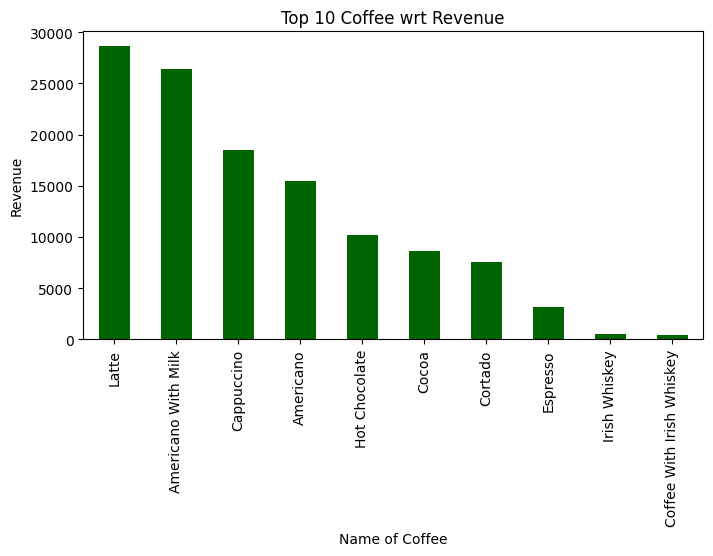

In [ ]:
revenue.head(10).plot(
    figsize=(8,4),
    kind='bar',
    x='coffee_name',
    y='money',
    legend=False,
    title="Top 10 Coffee wrt Revenue",
    color='darkgreen',
    xlabel='Name of Coffee',
    ylabel="Revenue"
)
plt.show()

In [ ]:
average_ticket_size=new_df.groupby('coffee_name')['money'].mean().sort_values(ascending=False).reset_index()
print("Average Ticket Size by Coffee")
print(average_ticket_size)

Average Ticket Size by Coffee
                   coffee_name      money
0                Hot Chocolate  36.072553
1                   Cappuccino  35.810716
2                        Cocoa  35.712593
3                        Latte  35.556203
4    Double Espresso With Milk  32.000000
5          Americano With Milk  30.379171
6                   Mochaccino  30.000000
7                Hot Milkshake  30.000000
8        Chocolate With Coffee  30.000000
9    Coffee With Irish Whiskey  29.000000
10        Double Irish Whiskey  28.000000
11  Vanilla With Irish Whiskey  28.000000
12             Super Chocolate  28.000000
13       Coffee With Chocolate  28.000000
14  Caramel With Irish Whiskey  28.000000
15              Caramel Coffee  28.000000
16      Caramel With Chocolate  28.000000
17         Chocolate With Milk  27.000000
18     Irish Whiskey With Milk  27.000000
19              Vanilla Coffee  27.000000
20        Irish With Chocolate  27.000000
21            Double Ristretto  27.000000
22  

In [ ]:
new_df['date']=pd.to_datetime(new_df['date'])
daily_sales=new_df.groupby('date')['money'].sum()
print(daily_sales)

date
2024-03-01    396.30
2024-03-02    228.10
2024-03-03    349.10
2024-03-04    135.20
2024-03-05    338.50
               ...  
2025-03-19    763.56
2025-03-20    685.60
2025-03-21    741.80
2025-03-22    613.42
2025-03-23    419.76
Name: money, Length: 381, dtype: float64


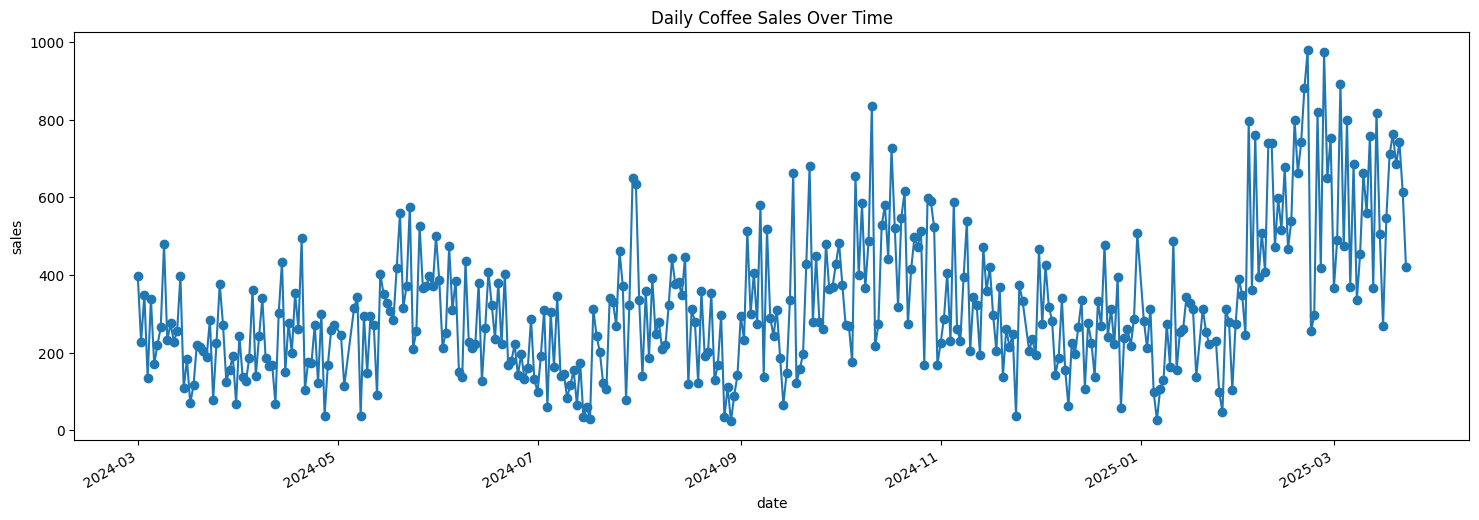

In [ ]:
daily_sales.plot(
    figsize=(18,6),
    kind="line",
    marker="o",
    grid=False,
    xlabel="date",
    ylabel="sales",
    title="Daily Coffee Sales Over Time"
)
plt.show()

In [ ]:
hourly_count=new_df.groupby("hour")["money"].count().reset_index()
print(hourly_count)

    hour  money
0    6.0      5
1    7.0     91
2    8.0    235
3    9.0    247
4   10.0    349
5   11.0    294
6   12.0    249
7   13.0    227
8   14.0    228
9   15.0    245
10  16.0    283
11  17.0    244
12  18.0    220
13  19.0    235
14  20.0    171
15  21.0    197
16  22.0    116


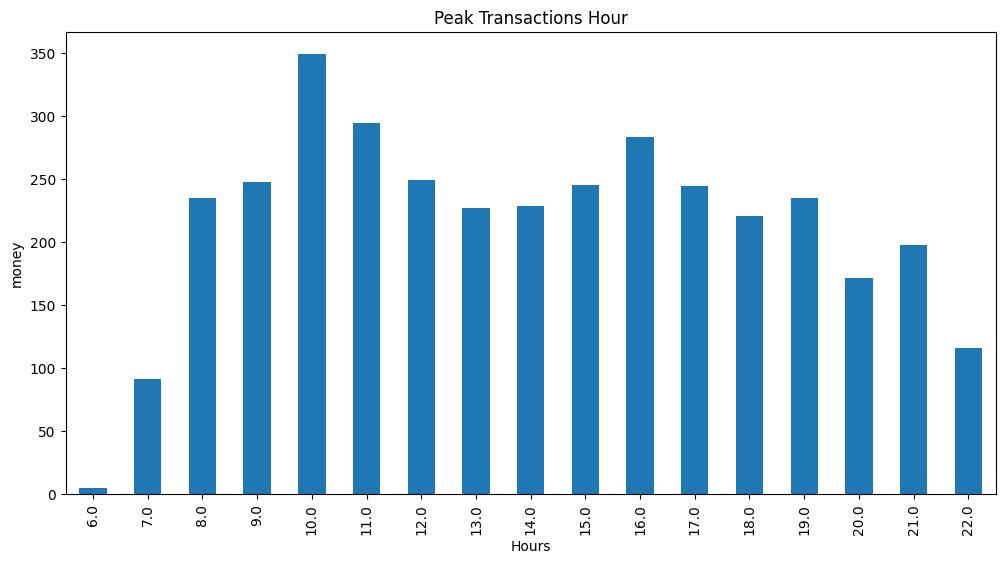

In [ ]:
hourly_count.plot(
    figsize=(12,6),
    kind='bar',
    x='hour',
    y='money',
    legend=False,
    xlabel="Hours",
    ylabel='money',
    title='Peak Transactions Hour'

)
plt.show()

In [ ]:
repeat_customers=new_df['card'].value_counts().reset_index()
print(repeat_customers)

                     card  count
0                 unknown    351
1     ANON-0000-0000-0012    129
2     ANON-0000-0000-0141    108
3     ANON-0000-0000-1163     77
4     ANON-0000-0000-0276     69
...                   ...    ...
1312  ANON-0000-0000-1300      1
1313  ANON-0000-0000-1299      1
1314  ANON-0000-0000-1296      1
1315  ANON-0000-0000-0015      1
1316  ANON-0000-0000-0014      1

[1317 rows x 2 columns]


In [ ]:
frequent_customer=repeat_customers[repeat_customers['count']>1]
print("Frequent customer(2+ orders")
print(frequent_customer)


Frequent customer(2+ orders
                    card  count
0                unknown    351
1    ANON-0000-0000-0012    129
2    ANON-0000-0000-0141    108
3    ANON-0000-0000-1163     77
4    ANON-0000-0000-0276     69
..                   ...    ...
541  ANON-0000-0000-0319      2
542  ANON-0000-0000-0320      2
543  ANON-0000-0000-0322      2
544  ANON-0000-0000-1008      2
545  ANON-0000-0000-0959      2

[546 rows x 2 columns]


In [ ]:
from datetime import date
new_df['date']=pd.to_datetime(new_df['date'],errors='coerce')
new_df['month']=new_df['date'].dt.month_name()
df_fm=new_df[new_df['month'].isin(['February','March'])]
monthly_orders=df_fm['month'].value_counts().reset_index()
monthly_orders.columns=['month','orders']
print(monthly_orders)

      month  orders
0     March     649
1  February     561


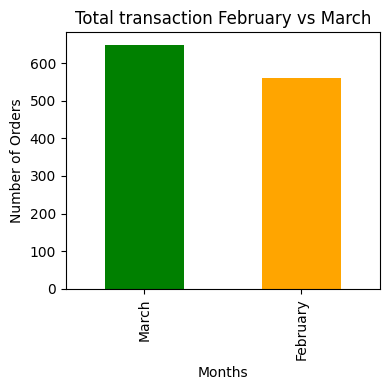

In [ ]:
monthly_orders.plot(
    figsize=(4,4),
    kind='bar',
    x='month',
    y='orders',
    title='Total transaction February vs March',
    xlabel='Months',
    ylabel='Number of Orders',
    legend=False,
    color=['Green','orange']

)
plt.tight_layout()
plt.show()

In [ ]:
avg_spend=df_fm.groupby('month')['money'].mean().reset_index()
print(avg_spend)

      month      money
0  February  29.954510
1     March  31.336888


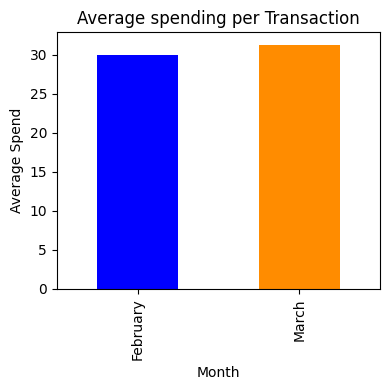

In [ ]:
avg_spend.plot(
    figsize=(4,4),
    kind='bar',
    x='month',
    y='money',
    title='Average spending per Transaction',
    color=['blue','darkorange'],
    legend=False,
    xlabel='Month',
    ylabel='Average Spend'
)
plt.tight_layout()
plt.show()

In [ ]:
coffee_month=(df_fm.groupby(['month','coffee_name']).size().reset_index(name='orders').sort_values(['month','orders'],ascending=[True,False]))
print(coffee_month.groupby('month').head(10))

       month                coffee_name  orders
0   February                  Americano     124
1   February        Americano With Milk     109
21  February                      Latte      70
2   February                 Cappuccino      61
10  February                      Cocoa      56
18  February              Hot Chocolate      32
17  February                   Espresso      31
24  February                        Tea      13
12  February                    Cortado      10
11  February  Coffee With Irish Whiskey       9
26     March                  Americano     146
49     March                      Latte     113
27     March        Americano With Milk     106
28     March                 Cappuccino      70
44     March              Hot Chocolate      45
36     March                      Cocoa      36
39     March                    Cortado      32
43     March                   Espresso      24
46     March              Irish Whiskey      17
47     March    Irish Whiskey With Milk 

In [ ]:
payment_by_month=df_fm.groupby(['month','cash_type']).size().reset_index(name="transactions")
print(payment_by_month)



      month cash_type  transactions
0  February      card           510
1  February      cash            51
2     March      card           589
3     March      cash            60


In [ ]:
pivot_payment=payment_by_month.pivot(index='cash_type',columns='month',values='transactions')
print(pivot_payment)

month      February  March
cash_type                 
card            510    589
cash             51     60


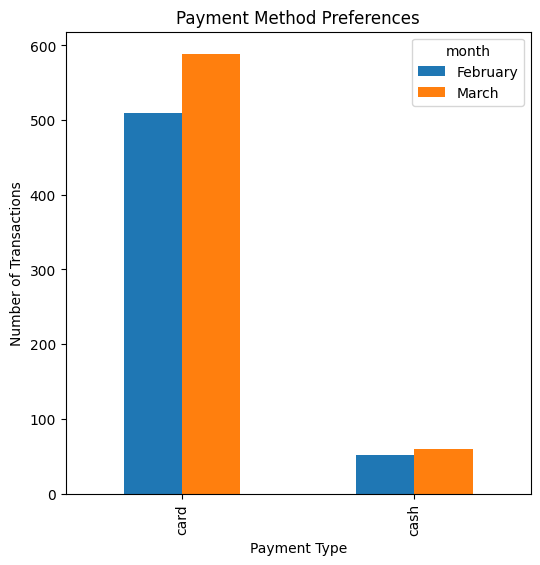

In [ ]:
pivot_payment.plot(
    figsize=(6,6),
    kind='bar',
    title='Payment Method Preferences',
    xlabel='Payment Type',
    ylabel='Number of Transactions'
)
plt.show()

In [ ]:
growth_trend=df_fm.groupby('month').agg(total_orders=('money','count'),total_revenue=('money','sum')).reset_index()
print(growth_trend)

      month  total_orders  total_revenue
0  February           561       16804.48
1     March           649       20337.64


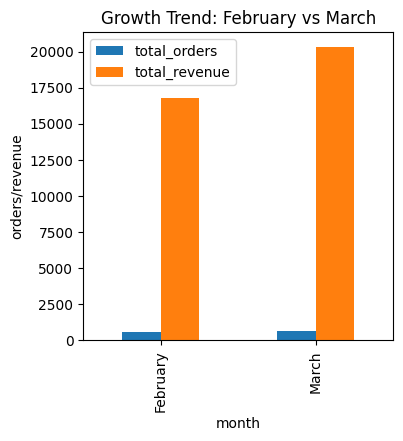

In [ ]:
growth_trend.plot(
    figsize=(4,4),
    kind='bar',
    x='month',
    y=['total_orders','total_revenue'],
    title='Growth Trend: February vs March',
    xlabel='month',
    ylabel='orders/revenue'
)
plt.show()

In [ ]:
payment_trends=df_fm.groupby(['month','cash_type']).size().reset_index(name='transactions')
print(payment_trends)

      month cash_type  transactions
0  February      card           510
1  February      cash            51
2     March      card           589
3     March      cash            60


In [ ]:
pivot_trend=payment_trends.pivot(index='cash_type',
                                 columns='month',
                                 values='transactions')
print(pivot_trend)

month      February  March
cash_type                 
card            510    589
cash             51     60


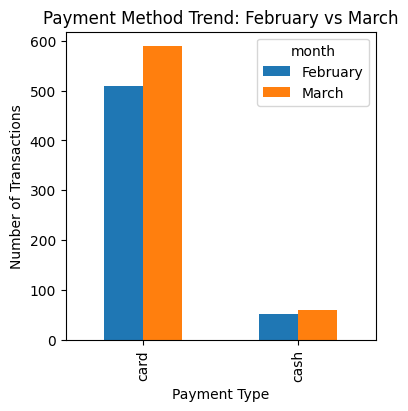

In [ ]:
pivot_trend.plot(
    figsize=(4,4),
    kind='bar',
    title='Payment Method Trend: February vs March',
    xlabel='Payment Type',
    ylabel='Number of Transactions'
)
plt.show()

In [ ]:
coffee_trend=df_fm.groupby(['month','coffee_name']).size().reset_index(name='orders')
print(coffee_trend)

       month                 coffee_name  orders
0   February                   Americano     124
1   February         Americano With Milk     109
2   February                  Cappuccino      61
3   February              Caramel Coffee       1
4   February      Caramel With Chocolate       3
5   February  Caramel With Irish Whiskey       5
6   February           Caramel With Milk       2
7   February                   Chocolate       1
8   February       Chocolate With Coffee       2
9   February         Chocolate With Milk       4
10  February                       Cocoa      56
11  February   Coffee With Irish Whiskey       9
12  February                     Cortado      10
13  February             Double Espresso       1
14  February   Double Espresso With Milk       2
15  February        Double Irish Whiskey       9
16  February              Double Vanilla       2
17  February                    Espresso      31
18  February               Hot Chocolate      32
19  February        

In [ ]:
pivot_coffee=coffee_trend.pivot(index='coffee_name',
                                columns='month',
                                values='orders').fillna(0)
print(pivot_coffee)

month                       February  March
coffee_name                                
Americano                      124.0  146.0
Americano With Milk            109.0  106.0
Cappuccino                      61.0   70.0
Caramel                          0.0    1.0
Caramel Coffee                   1.0    1.0
Caramel With Chocolate           3.0    1.0
Caramel With Irish Whiskey       5.0    3.0
Caramel With Milk                2.0    1.0
Chocolate                        1.0    0.0
Chocolate With Coffee            2.0    3.0
Chocolate With Milk              4.0    8.0
Cocoa                           56.0   36.0
Coffee With Chocolate            0.0    1.0
Coffee With Irish Whiskey        9.0    7.0
Cortado                         10.0   32.0
Double Chocolate                 0.0    1.0
Double Espresso                  1.0    0.0
Double Espresso With Milk        2.0    0.0
Double Irish Whiskey             9.0    3.0
Double Ristretto                 0.0    1.0
Double Vanilla                  

In [ ]:
if 'February'in pivot_coffee.columns and 'March'in pivot_coffee.columns:
  pivot_coffee['growth%']=((pivot_coffee['March']-pivot_coffee['February'])/pivot_coffee['February'].replace(0,pd.NA))*100

In [ ]:
print(pivot_coffee[['growth%']])

month                         growth%
coffee_name                          
Americano                   17.741935
Americano With Milk         -2.752294
Cappuccino                  14.754098
Caramel                          <NA>
Caramel Coffee                    0.0
Caramel With Chocolate     -66.666667
Caramel With Irish Whiskey      -40.0
Caramel With Milk               -50.0
Chocolate                      -100.0
Chocolate With Coffee            50.0
Chocolate With Milk             100.0
Cocoa                      -35.714286
Coffee With Chocolate            <NA>
Coffee With Irish Whiskey  -22.222222
Cortado                         220.0
Double Chocolate                 <NA>
Double Espresso                -100.0
Double Espresso With Milk      -100.0
Double Irish Whiskey       -66.666667
Double Ristretto                 <NA>
Double Vanilla                 -100.0
Espresso                   -22.580645
Hot Chocolate                  40.625
Hot Milkshake                    <NA>
Irish Whiske

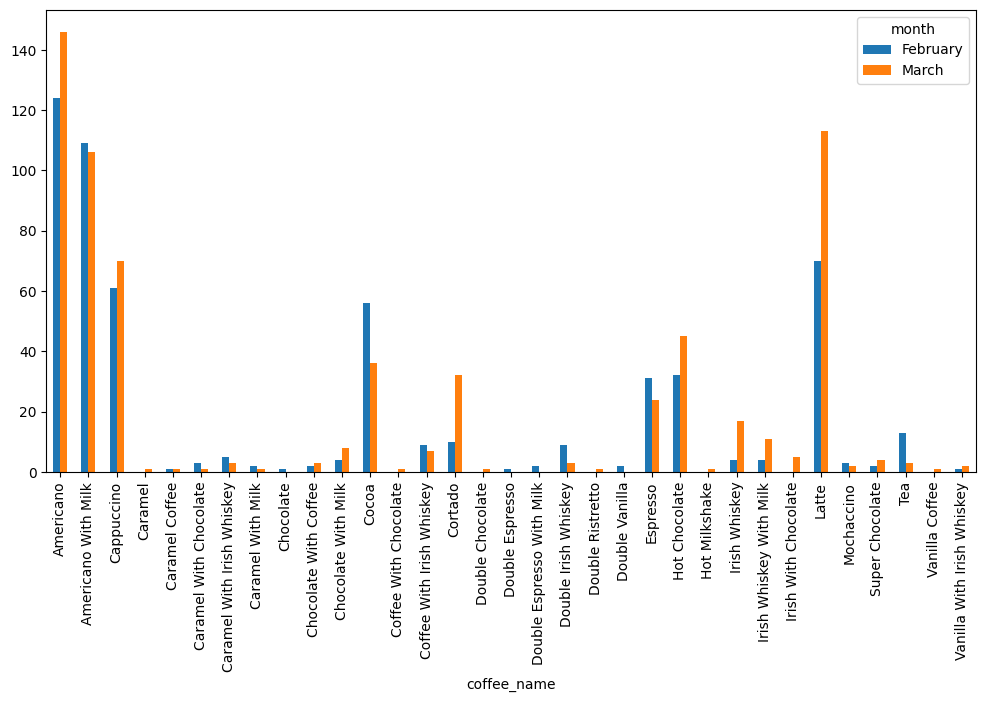

In [ ]:
pivot_coffee[['February','March']].plot(
    figsize=(12,6),
    kind='bar'
)
plt.show()

In [ ]:
top_coffees = (
    df_fm['coffee_name'].value_counts().head(5).index
)
filtered = pivot_coffee.loc[pivot_coffee.index.isin(top_coffees)]

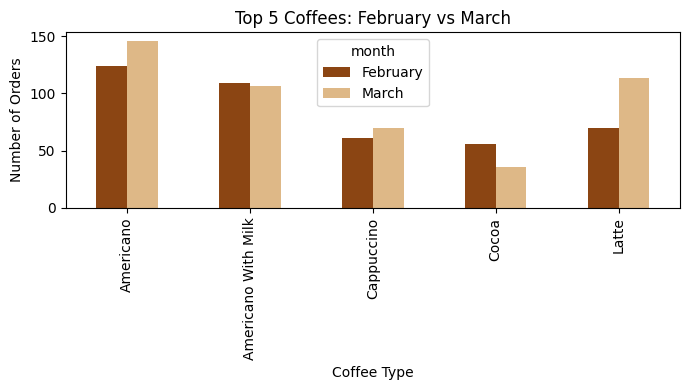

In [ ]:
filtered = pivot_coffee.loc[pivot_coffee.index.isin(top_coffees)]

filtered[['February', 'March']].plot(
    kind='bar',
    figsize=(7,4),
    color=['#8B4513', '#DEB887'],
    title='Top 5 Coffees: February vs March',
    xlabel="Coffee Type",
    ylabel="Number of Orders"
)

plt.tight_layout()
plt.show()

In [ ]:
new_df.head()

,date,datetime,cash_type,card,money,coffee_name,hour,month
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,10.0,March
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12.0,March
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12.0,March
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,13.0,March
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,13.0,March
